In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
import utils

GRAPH_ASSORTATIVITY_FILE = "results/graph_assortativity.tsv"
GRAPH_DEGREE_FIT_FILE = "results/graph_degree_fit.tsv"

# Analysis of degree distributions

In this notebook we analyze the degree distributions of ERC-1155 Token Transfer Graphs.

In [2]:
fdf = pl.read_csv(GRAPH_DEGREE_FIT_FILE, separator='\t', null_values=["null"])
fdf

contract_id,measure,alpha,x_min,L,D,p_value
i64,str,f64,i64,f64,f64,f64
0,"""in_deg""",2.20158,1,-1.13326e6,0.008911,0.0
0,"""out_deg""",1.86229,1,-700598.0,0.0111688,0.0
1,"""in_deg""",2.10975,1,-119055.0,0.0141621,0.0
1,"""out_deg""",2.45334,23,-10029.9,0.009604,0.6792
2,"""in_deg""",2.06203,2,-69932.5,0.0271482,0.0
…,…,…,…,…,…,…
33416,"""out_deg""",null,null,null,null,null
33417,"""in_deg""",null,null,null,null,null
33417,"""out_deg""",null,null,null,null,null


In [3]:
x = fdf.drop_nulls().group_by('contract_id').agg(pl.col("measure"))
in_only = x.filter((pl.col("measure").list.contains("in_deg")) & ~(pl.col("measure").list.contains("out_deg")))
out_only = x.filter((pl.col("measure").list.contains("out_deg")) & ~(pl.col("measure").list.contains("in_deg")))
both = x.filter((pl.col("measure").list.contains("in_deg")) & (pl.col("measure").list.contains("out_deg")))
print(f"Total number of networks: {fdf['contract_id'].n_unique()}")
print(f'In-degree only: {len(in_only)}')
print(f'Out-degree only: {len(out_only)}')
print(f'In and out-degree: {len(both)}')

Total number of networks: 16319
In-degree only: 3605
Out-degree only: 334
In and out-degree: 9271


In [34]:
len(out_only) + len(both)

9605

In [4]:
fdf_in = fdf.filter(pl.col("measure") == "in_deg")
fdf_out = fdf.filter(pl.col("measure") == "out_deg")

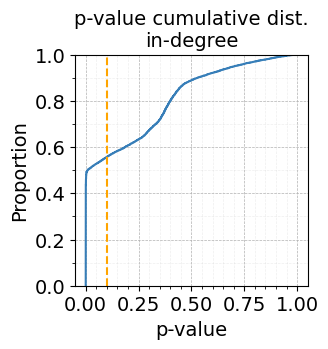

In [27]:
data = fdf_in['p_value']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('p-value cumulative dist.\nin-degree')
ax.set_xlabel('p-value')
sns.ecdfplot(data, color='#377eb8', ax=ax)
ax.axvline(x=0.1, color='orange', linestyle='--')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-p-cumul-in.pdf", format='pdf', bbox_inches='tight')
plt.show()

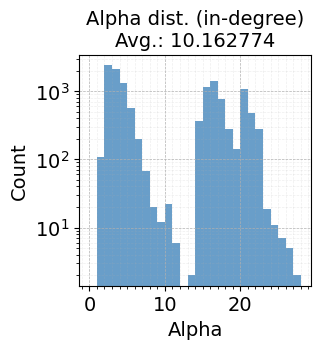

In [28]:
data = fdf_in['alpha']
avg_value = data.mean()
bins = np.arange(0, data.max()+1)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Alpha dist. (in-degree)\nAvg.: {:.6f}'.format(avg_value))
ax.set_xlabel('Alpha')
ax.set_yscale('log')
sns.histplot(data, bins=bins, color='#377eb8', edgecolor="none", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(10))
#ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-alpha-in.pdf", format='pdf', bbox_inches='tight')
plt.show()


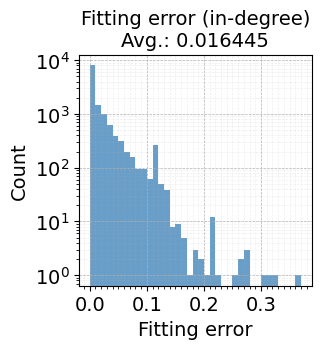

In [29]:
data = fdf_in['D']
avg_value = data.mean()
step = 0.01
bins = np.arange(0, data.max()+step, step)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Fitting error (in-degree)\nAvg.: {:.6f}'.format(avg_value))
ax.set_xlabel('Fitting error')
ax.set_yscale('log')
sns.histplot(data, bins=bins, color='#377eb8', edgecolor="none", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(10))
#ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-error-in.pdf", format='pdf', bbox_inches='tight')
plt.show()

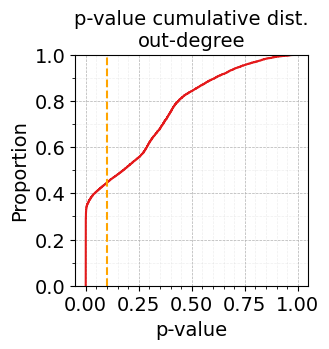

In [30]:
data = fdf_out['p_value']
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('p-value cumulative dist.\nout-degree')
ax.set_xlabel('p-value')
sns.ecdfplot(data, color='#e41a1c', ax=ax)
ax.axvline(x=0.1, color='orange', linestyle='--')
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-p-cumul-out.pdf", format='pdf', bbox_inches='tight')
plt.show()

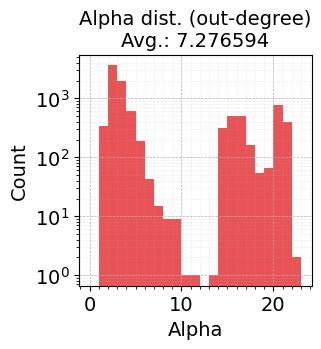

In [31]:
data = fdf_out['alpha']
avg_value = data.mean()
bins = np.arange(0, data.max()+1)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Alpha dist. (out-degree)\nAvg.: {:.6f}'.format(avg_value))
ax.set_xlabel('Alpha')
ax.set_yscale('log')
sns.histplot(data, bins=bins, color='#e41a1c', edgecolor="none", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(10))
#ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-alpha-out.pdf", format='pdf', bbox_inches='tight')
plt.show()

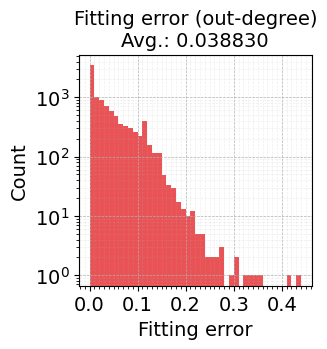

In [32]:
data = fdf_out['D']
avg_value = data.mean()
step = 0.01
bins = np.arange(0, data.max()+step, step)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Fitting error (out-degree)\nAvg.: {:.6f}'.format(avg_value))
ax.set_xlabel('Fitting error')
ax.set_yscale('log')
sns.histplot(data, bins=bins, color='#e41a1c', edgecolor="none", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.xaxis.set_minor_locator(AutoMinorLocator(10))
#ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-error-out.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [2]:
adf = pl.read_csv('results/graph_assortativity_all.tsv', separator='\t', null_values=["nan", "-nan"])
#tmp = pl.read_csv('results/graph_centralization.tsv', separator='\t', null_values=["null"])
#adf = adf.join(tmp.select('contract_id', 'address', 'in_cent', 'out_cent'), on='contract_id', how='left')
adf

contract_id,num_nodes,num_edges,in_in,in_out,out_in,out_out,elapsed
i64,i64,i64,f64,f64,f64,f64,i64
0,938630,2261588,-0.006859,0.006407,-0.037293,-0.024726,1580480604
1,81542,329122,0.0521754,0.0414009,-0.196221,-0.119753,156553201
2,102458,322871,-0.086186,-0.00123,-0.144106,-0.02734,158973327
3,90830,262459,0.0217216,0.0230378,-0.228375,-0.129059,127646916
4,161557,248259,-0.045882,-0.014731,-0.093579,-0.027709,127280606
…,…,…,…,…,…,…,…
33411,3,2,null,-1.0,null,null,133943
33414,3,2,null,-1.0,null,null,100744
33416,3,2,null,-1.0,null,null,127745


In [3]:
finite_in_in = adf['in_in'].is_finite().sum()
finite_in_out = adf['in_out'].is_finite().sum()
finite_out_in = adf['out_in'].is_finite().sum()
finite_out_out = adf['out_out'].is_finite().sum()
print(f'Finite in_in assortativity: {finite_in_in}')
print(f'Finite in_out assortativity: {finite_in_out}')
print(f'Finite out_in assortativity: {finite_out_in}')
print(f'Finite out_out assortativity: {finite_out_out}')

Finite in_in assortativity: 6873
Finite in_out assortativity: 11576
Finite out_in assortativity: 6783
Finite out_out assortativity: 10044


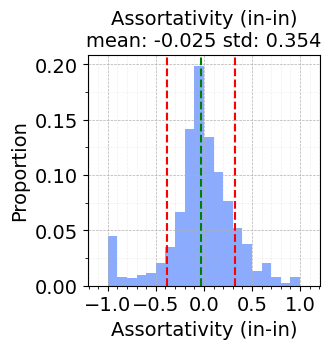

In [5]:
data = adf['in_in']
mean_value = data.mean()
std_value = data.std()
step = 0.1
bins = np.arange(-1-step, 1+2*step, step)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Assortativity (in-in)\nmean: {:.3f} std: {:.3f}'.format(mean_value, std_value))
ax.set_xlabel('Assortativity (in-in)')
sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", stat="proportion", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.axvline(x=mean_value, color='green', linestyle='--')
ax.axvline(x=mean_value+std_value, color='red', linestyle='--')
ax.axvline(x=mean_value-std_value, color='red', linestyle='--')
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-assortativity-ii.pdf", format='pdf', bbox_inches='tight')
plt.show()

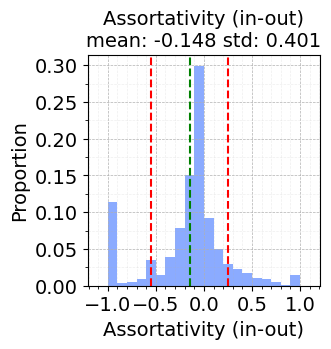

In [6]:
data = adf['in_out']
mean_value = data.mean()
std_value = data.std()
step = 0.1
bins = np.arange(-1-step, 1+2*step, step)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Assortativity (in-out)\nmean: {:.3f} std: {:.3f}'.format(mean_value, std_value))
ax.set_xlabel('Assortativity (in-out)')
sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", stat="proportion", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.axvline(x=mean_value, color='green', linestyle='--')
ax.axvline(x=mean_value+std_value, color='red', linestyle='--')
ax.axvline(x=mean_value-std_value, color='red', linestyle='--')
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-assortativity-io.pdf", format='pdf', bbox_inches='tight')
plt.show()

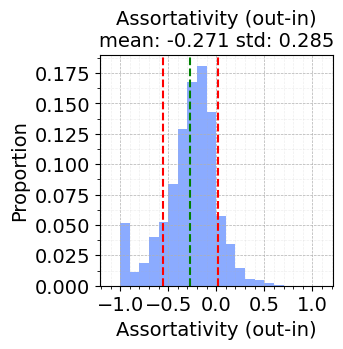

In [7]:
data = adf['out_in']
mean_value = data.mean()
std_value = data.std()
step = 0.1
bins = np.arange(-1-step, 1+2*step, step)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Assortativity (out-in)\nmean: {:.3f} std: {:.3f}'.format(mean_value, std_value))
ax.set_xlabel('Assortativity (out-in)')
sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", stat="proportion", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.axvline(x=mean_value, color='green', linestyle='--')
ax.axvline(x=mean_value+std_value, color='red', linestyle='--')
ax.axvline(x=mean_value-std_value, color='red', linestyle='--')
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-assortativity-oi.pdf", format='pdf', bbox_inches='tight')
plt.show()

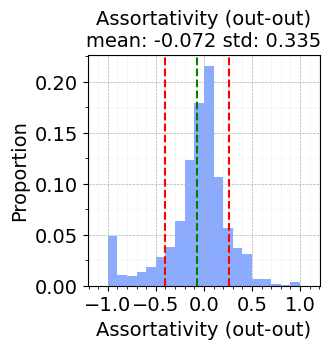

In [8]:
data = adf['out_out']
mean_value = data.mean()
std_value = data.std()
step = 0.1
bins = np.arange(-1-step, 1+2*step, step)
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title('Assortativity (out-out)\nmean: {:.3f} std: {:.3f}'.format(mean_value, std_value))
ax.set_xlabel('Assortativity (out-out)')
sns.histplot(data, bins=bins, color='#648fff', edgecolor="none", stat="proportion", ax=ax)
ax.grid(which='major', linestyle='--', linewidth=0.5)
ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.2)
ax.axvline(x=mean_value, color='green', linestyle='--')
ax.axvline(x=mean_value+std_value, color='red', linestyle='--')
ax.axvline(x=mean_value-std_value, color='red', linestyle='--')
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
utils.set_font_size(ax, 14)
plt.savefig("figures/degree-assortativity-oo.pdf", format='pdf', bbox_inches='tight')
plt.show()